In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from helper import generate_trajectories, export_animation_json

Ps, hotspots = generate_trajectories(5, 60)
export_animation_json(Ps, hotspots, path="trajectories.json")


# 2.1

## 2.1.1. Two Trajectories

In [ ]:
# Generate two random trajectories with hotspots
N = 2  # number of trajectories
steps = 10  # number of time steps
Ps, hotspots = generate_trajectories(2, 10)


# Visualize the trajectories and hotspots
fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(Ps[0][:, 0], Ps[0][:, 1], label="Trajectory 1", marker="o", linestyle="-")
ax.plot(Ps[1][:, 0], Ps[1][:, 1], label="Trajectory 2", marker="o", linestyle="-")

# Mark trajectory with time steps
for i in range(Ps.shape[1]):
    ax.text(Ps[0][i, 0], Ps[0][i, 1], str(i), fontsize=10, color="blue")
    ax.text(Ps[1][i, 0], Ps[1][i, 1], str(i), fontsize=10, color="orange")

# Mark hotspots
for i, hotspot in enumerate(hotspots):
    ax.plot(hotspot.x, hotspot.y, "ro")

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_title("Trajectories and Hotspots")
ax.legend()
plt.show()

In [ ]:
# Export the trajectories and hotspots to JSON for animation
from helper import export_animation_json

export_animation_json(Ps, hotspots, path="trajectories.json")
# Run: pixi run python problem2/animate.py problem2/trajectories.json

In [ ]:
import chex
import jax.numpy as jnp
from stljax.formula import Predicate, GreaterThan, LessThan, Always, Eventually, And

from config import Hotspot, Hotspot3D

# Default parameters. Keep these values for the submission.
EPS_START = 25.0  # tolerance for start position
EPS_CONV = 30.0  # tolerance for convergence hotspot
EPS_DIV = 30.0  # tolerance for divergence hotspot
EPS_END = 25.0  # tolerance for end position
DELTA_BUNDLE = 50.0  # max pairwise distance for bundling
DELTA_MIN = 5.0  # min pairwise distance for separation
ALPHA_MAX = 15.0  # max acceleration magnitude for smoothness


def hotspot_pos(h: Hotspot) -> chex.Array:
    return jnp.array([h.x, h.y])


def compute_bundling_robustness(
    Ps: chex.Array, hotspots: list[Hotspot], bundle_threshold: float = DELTA_BUNDLE
) -> chex.Numeric:
    """TODO. Implement the function that computes bundling robustness"""
    pass


def compute_separation_robustness(
    Ps: chex.Array, hotspots: list[Hotspot], min_dist: float = DELTA_MIN
) -> chex.Numeric:
    """TODO. Implement the function that computes separation robustness"""
    pass


def compute_smoothness_robustness(
    Ps: chex.Array, max_accel: float = ALPHA_MAX
) -> chex.Numeric:
    """TODO. Implement the function that computes smoothness robustness"""
    pass


def compute_position_robustness(
    Ps: chex.Array,
    hotspots: list[Hotspot],
    eps_start: float = EPS_START,
    eps_conv: float = EPS_CONV,
    eps_div: float = EPS_DIV,
    eps_end: float = EPS_END,
) -> chex.Numeric:
    """TODO. Implement the function that computes position robustness for start, convergence, divergence, and end conditions.
    - For convergence/divergence, compute the distance to the respective hotspot at the specified time step and return robustness = eps - distance.
    - For start/end, compute the distance to the respective target position at the respective time step and return robustness = eps - distance.
    - The overall robustness is the minimum of all these values across all trajectories.
    - Note: For start/end, since the trajectories are generated to start/end at specific positions, you can directly use eps_start and eps
    """
    pass

In [ ]:
# Compute robustness values for the two trajectories generated above.

bundling_robustness = compute_bundling_robustness(Ps, hotspots)
assert bundling_robustness is not None, (
    "compute_bundling_robustness is not implemented yet."
)
print(f"Bundling robustness:  {bundling_robustness:.4f}")

separation_robustness = compute_separation_robustness(Ps, hotspots)
assert separation_robustness is not None, (
    "compute_separation_robustness is not implemented yet."
)
print(f"Separation robustness: {separation_robustness:.4f}")

smoothness_robustness = compute_smoothness_robustness(Ps)
assert smoothness_robustness is not None, (
    "compute_smoothness_robustness is not implemented yet."
)
print(f"Smoothness robustness: {smoothness_robustness:.4f}")

position_robustness = compute_position_robustness(Ps, hotspots)
assert position_robustness is not None, (
    "compute_position_robustness is not implemented yet."
)
print(f"Position robustness:  {position_robustness:.4f}")

## 2.1.2. Multiple 2D Trajectoris

In [ ]:
N = 3
steps = 10
Ps, hotspots = generate_trajectories(N, steps)
print(Ps.shape)

# Visualize the trajectories and hotspots
fig, ax = plt.subplots(figsize=(8, 8))

for i in range(Ps.shape[0]):
    ax.plot(
        Ps[i][:, 0], Ps[i][:, 1], label=f"Trajectory {i + 1}", marker="o", linestyle="-"
    )

# Mark trajectory with time steps
for i in range(Ps.shape[1]):
    for j in range(Ps.shape[0]):
        ax.text(Ps[j][i, 0], Ps[j][i, 1], str(i), fontsize=10)


# Mark hotspots
for i, hotspot in enumerate(hotspots):
    ax.plot(hotspot.x, hotspot.y, "ro")

ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.set_title("Trajectories and Hotspots")
ax.legend()
plt.show()


In [ ]:
# 2.1.2: Compute robustness for N ∈ {3, 5, 10} trajectories
results = []
for N in [3, 5, 10]:
    Ps, hotspots = generate_trajectories(N, steps, seed=42)
    # TODO: Compute robustness values for each specification and store in results

# 2.2. Optimizing Animations

## 2.2.1. Optimizing Two Trajectories

In [ ]:
N = 2  # number of trajectories
steps = 10  # number of time steps
Ps, hotspots = generate_trajectories(N, steps)

In [ ]:
import jax
import optax


def bundling_loss(
    pos: chex.Array, hotspots: list[Hotspot], bundle_threshold: float = DELTA_BUNDLE
) -> chex.Numeric:
    """TODO. Implement the differentiable loss function for bundling robustness."""
    pass


def separation_loss(pos: chex.Array, min_dist: float = DELTA_MIN) -> chex.Numeric:
    """TODO. Implement the differentiable loss function for separation robustness."""
    pass


def smoothness_loss(pos: chex.Array) -> chex.Numeric:
    """TODO. Implement the differentiable loss function for smoothness robustness."""
    pass


def position_loss(
    pos: chex.Array,
    traj_in: chex.Array,
    hotspots: list[Hotspot],
    eps_conv: float = EPS_CONV,
    eps_div: float = EPS_DIV,
) -> chex.Numeric:
    """TODO. Implement the differentiable loss function for position correctness."""
    pass


def total_loss(
    pos: chex.Array,
    traj_in: chex.Array,
    hotspots: list[Hotspot],
    w_bundle: float = 0.5,
    w_smooth: float = 0.1,
    w_sep: float = 0.2,
    w_pos: float = 1.0,
) -> chex.Numeric:
    """Total optimization objective (minimize).
    Feel free to adjust the weights and loss terms as needed to achieve good optimization results.
    """
    l_bundle = bundling_loss(pos, hotspots)
    l_smooth = smoothness_loss(pos)
    l_sep = separation_loss(pos)
    l_pos = position_loss(pos, traj_in, hotspots)

    loss = w_bundle * l_bundle + w_smooth * l_smooth + w_sep * l_sep + w_pos * l_pos
    return loss


def optimize(
    traj_in: chex.Array,
    hotspots: list[Hotspot],
    n_steps: int = 500,
    lr: float = 1e-2,
    log_every: int = 50,
    **loss_kwargs,
) -> tuple[chex.Array, dict]:
    """Optimize trajectory positions using Adam.

    Args:
        traj_in:  (N, K, 2) input trajectories
        hotspots: list of Hotspot objects
        n_steps:  number of gradient steps
        lr:       Adam learning rate
        log_every: logging interval
        **loss_kwargs: weight overrides (w_stl, w_smooth, w_deviation, w_sep, w_pos)

    Returns:
        pos_opt:  (K, N, 2) optimized positions
        history:  dict with 'loss' and 'step' lists
    """
    traj_jax = jnp.array(traj_in, dtype=jnp.float32)
    # Initialize pos from input trajectories (transpose to time-major)
    pos = jnp.transpose(traj_jax, (1, 0, 2))  # (K, N, 2)

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(pos)

    @jax.jit
    def step(
        pos: chex.Array, opt_state: optax.OptState
    ) -> tuple[chex.Array, optax.OptState, chex.Numeric]:
        loss_val, grads = jax.value_and_grad(total_loss)(
            pos, traj_jax, hotspots, **loss_kwargs
        )
        updates, new_state = optimizer.update(grads, opt_state)
        new_pos = optax.apply_updates(pos, updates)
        return new_pos, new_state, loss_val

    history = {"loss": [], "step": []}
    print(f"Optimizing: {n_steps} steps, lr={lr}")
    for i in range(n_steps):
        pos, opt_state, loss_val = step(pos, opt_state)
        if i % log_every == 0 or i == n_steps - 1:
            lv = float(loss_val)
            history["loss"].append(lv)
            history["step"].append(i)
            if i % (log_every * 5) == 0 or i == n_steps - 1:
                print(f"  step {i:5d}/{n_steps}  loss = {lv:.4f}")

    pos_opt = np.array(pos)
    return pos_opt, history

In [ ]:
# Run optimization for N=2
pos_opt, history = optimize(Ps, hotspots, n_steps=500, lr=1e-1, log_every=50)


Ps_opt = np.transpose(pos_opt, (1, 0, 2))

# Loss curve
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history["step"], history["loss"], lw=2)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Optimization Convergence")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compare robustness: before vs after
print(f"{'Metric':<22} {'Original':>10} {'Optimized':>10}")
print("-" * 44)
for name, fn in [
    ("Bundling", lambda P: compute_bundling_robustness(P, hotspots)),
    ("Separation", lambda P: compute_separation_robustness(P, hotspots)),
    ("Smoothness", lambda P: compute_smoothness_robustness(P)),
    ("Position", lambda P: compute_position_robustness(P, hotspots)),
]:
    orig = fn(Ps)
    opt = fn(Ps_opt)
    print(f"{name:<22} {orig:>10.4f} {opt:>10.4f}")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, data, title in [(axes[0], Ps, "Original"), (axes[1], Ps_opt, "Optimized")]:
    for i in range(data.shape[0]):
        ax.plot(data[i][:, 0], data[i][:, 1], marker="o", label=f"Traj {i + 1}")
        for t in range(data.shape[1]):
            ax.text(data[i][t, 0], data[i][t, 1], str(t), fontsize=8)
    for h in hotspots:
        color = "red" if h.kind == "converge" else "blue"
        ax.plot(
            h.x,
            h.y,
            "o",
            color=color,
            markersize=12,
            alpha=0.5,
            label=f"{h.kind} (t={h.time_step})",
        )
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

# Export optimized animation
export_animation_json(Ps_opt, hotspots, path="trajectories_optimized.json")
print("Run: pixi run python problem2/animate.py problem2/trajectories_optimized.json")

### 2.2.1 Sensitivity Analysis

Adjust the weight parameters to observe how the optimized trajectories change when different losses are prioritized.

In [ ]:
# Re-generate N=2 trajectories for consistency
N = 2
steps = 10
Ps_2, hotspots_2 = generate_trajectories(N, steps, seed=42)

# TODO. Adjust the parameters and observe how the robustness values change.
# You can also visualize the trajectories to see how the parameters affect the trajectoreis.

## 2.2.2. Optimizing Multiple Trajectories

In [ ]:
N = 10  # number of trajectories
steps = 60  # number of time steps
Ps, hotspots = generate_trajectories(N, steps)

In [ ]:
# TODO. The loss functions should already support arbitrary N, but if not, write a new one or rewrite the one you wrote above.
pos_opt_10, history_10 = optimize(Ps, hotspots, n_steps=1000, lr=5e-2, log_every=100)

# Convert back to object-major for evaluation
Ps_opt_10 = np.transpose(pos_opt_10, (1, 0, 2))

# Loss curve
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(history_10["step"], history_10["loss"], lw=2)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("2.2.2 Optimization Convergence (N=10, K=60)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# TODO.  Visual comparison of original vs optimized trajectories


In [ ]:
# TODO. Sensitivity Analysis. See how the change in parameters affect the optimization results.

# 2.3. 3D Trajectory Optimization

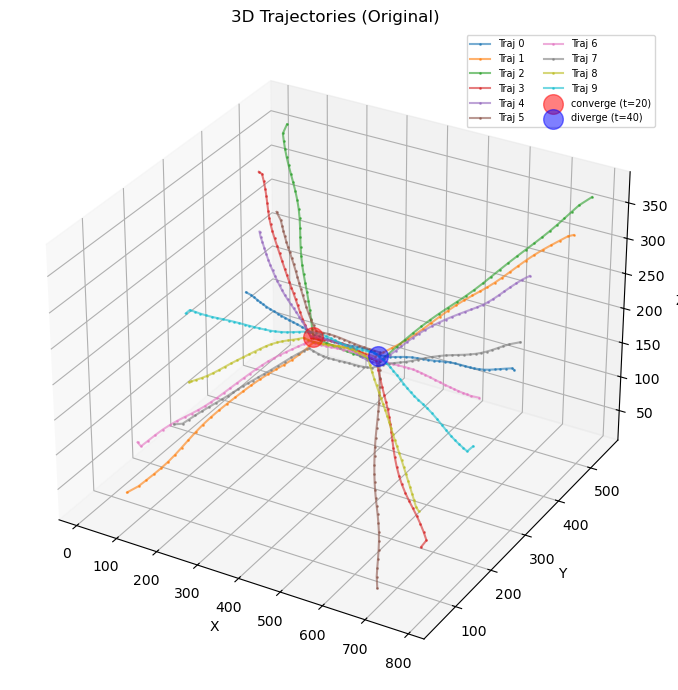

In [13]:
import matplotlib.pyplot as plt

from helper import generate_trajectories_3d
from config import Hotspot3D

# Quick 3D scatter to verify data
from mpl_toolkits.mplot3d import Axes3D


# Generate 3D trajectories
N_3d = 10
steps_3d = 60
Ps_3d, hotspots_3d = generate_trajectories_3d(N_3d, steps_3d, seed=42)


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
for i in range(Ps_3d.shape[0]):
    ax.plot(
        Ps_3d[i, :, 0],
        Ps_3d[i, :, 1],
        Ps_3d[i, :, 2],
        marker=".",
        markersize=2,
        alpha=0.6,
        label=f"Traj {i}",
    )
for h in hotspots_3d:
    color = "red" if h.kind == "converge" else "blue"
    ax.scatter(
        h.x,
        h.y,
        h.z,
        color=color,
        s=200,
        alpha=0.5,
        label=f"{h.kind} (t={h.time_step})",
    )
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Trajectories (Original)")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

In [14]:
import rerun as rr

# Rerun: Log original (pre-optimization) 3D trajectories
rr.init("3d_trajectories_original")
rr.save("trajectories_3d_original.rrd")

COLORS_RR = [
    [231, 76, 60],
    [52, 152, 219],
    [46, 204, 113],
    [155, 89, 182],
    [243, 156, 18],
    [26, 188, 156],
    [230, 126, 34],
    [52, 73, 94],
    [149, 165, 166],
    [192, 57, 43],
    [41, 128, 185],
    [39, 174, 96],
    [142, 68, 173],
    [211, 84, 0],
    [22, 160, 133],
    [127, 140, 141],
]

N_traj = Ps_3d.shape[0]
K_steps = Ps_3d.shape[1]

# Log hotspots as static spheres
for h in hotspots_3d:
    color = [255, 0, 0] if h.kind == "converge" else [0, 100, 255]
    rr.log(
        f"hotspots/{h.kind}",
        rr.Points3D(
            positions=[[h.x, h.y, h.z]],
            radii=[15.0],
            colors=[color],
            labels=[f"{h.kind} (t={h.time_step})"],
        ),
        static=True,
    )

# Log full trajectory paths as static line strips
for i in range(N_traj):
    color = COLORS_RR[i % len(COLORS_RR)]
    rr.log(
        f"paths/traj_{i}",
        rr.LineStrips3D(strips=[Ps_3d[i].tolist()], colors=[color]),
        static=True,
    )

# Log animated positions per time step
for t in range(K_steps):
    rr.set_time("frame", sequence=t)
    rr.log(
        "positions",
        rr.Points3D(
            positions=Ps_3d[:, t, :].tolist(),
            radii=[4.0] * N_traj,
            colors=[COLORS_RR[i % len(COLORS_RR)] for i in range(N_traj)],
        ),
    )

print("Saved to trajectories_3d_original.rrd")
print("View from CLI:  pixi run rerun problem2/trajectories_3d_original.rrd")

Saved to trajectories_3d_original.rrd
View from CLI:  pixi run rerun problem2/trajectories_3d_original.rrd


## 3D STL Specifications and Loss Functions

Adapt all four STL robustness functions and loss functions to work with 3D positions of shape `(K, N, 3)`. The core logic is identical to the 2D versions — all distance and acceleration computations now operate in R^3.

In [ ]:
def hotspot_pos_3d(h: Hotspot3D) -> chex.Array:
    """Return hotspot position as a JAX array (3D)."""
    return jnp.array([h.x, h.y, h.z])


def compute_bundling_robustness_3d(
    Ps: chex.Array, hotspots: list[Hotspot3D], bundle_threshold: float = DELTA_BUNDLE
) -> chex.Numeric:
    """TODO. Implement the function that computes bundling robustness for 3D trajectories."""
    pass


def compute_separation_robustness_3d(
    Ps: chex.Array, hotspots: list[Hotspot3D], min_dist: float = DELTA_MIN
) -> chex.Numeric:
    """TODO. Implement the function that computes separation robustness for 3D trajectories."""
    pass


def compute_smoothness_robustness_3d(
    Ps: chex.Array, max_accel: float = ALPHA_MAX
) -> chex.Numeric:
    """TODO. Implement the function that computes smoothness robustness for 3D trajectories."""
    pass


def compute_position_robustness_3d(
    Ps: chex.Array,
    hotspots: list[Hotspot3D],
    eps_start: float = EPS_START,
    eps_conv: float = EPS_CONV,
    eps_div: float = EPS_DIV,
    eps_end: float = EPS_END,
) -> chex.Numeric:
    """TODO. Implement the function that computes position robustness for 3D trajectories."""
    pass


# 3D Differentiable Loss Functions (in case your 2D loss functions don't already support 3D)
def bundling_loss_3d(
    pos: chex.Array, hotspots: list[Hotspot3D], bundle_threshold: float = DELTA_BUNDLE
) -> chex.Numeric:
    """TODO: Write a differentiable loss function for bundling robustness in 3D pos."""
    pass


def separation_loss_3d(pos: chex.Array, min_dist: float = DELTA_MIN) -> chex.Numeric:
    """TODO: Write a differentiable loss function for separation robustness in 3D pos."""
    pass


def smoothness_loss_3d(pos: chex.Array) -> chex.Numeric:
    """TODO: Write a differentiable loss function for smoothness robustness in 3D."""
    pass


def position_loss_3d(
    pos: chex.Array, traj_in: chex.Array, hotspots: list[Hotspot3D]
) -> chex.Numeric:
    """TODO: Write a differentiable loss function for position correctness in 3D."""
    pass


def total_loss_3d(
    pos: chex.Array,
    traj_in: chex.Array,
    hotspots: list[Hotspot3D],
    w_bundle: float = 1.0,
    w_smooth: float = 0.1,
    w_sep: float = 0.2,
    w_pos: float = 1.0,
) -> chex.Numeric:
    """Total 3D optimization objective (minimize). Feel free to adjust the weights and loss terms as needed to achieve good optimization results."""
    l_bundle = bundling_loss_3d(pos, hotspots)
    l_smooth = smoothness_loss_3d(pos)
    l_sep = separation_loss_3d(pos)
    l_pos = position_loss_3d(pos, traj_in, hotspots)

    return w_bundle * l_bundle + w_smooth * l_smooth + w_sep * l_sep + w_pos * l_pos


# Optimization Loop
def optimize_3d(
    traj_in: chex.Array,
    hotspots: list[Hotspot3D],
    n_steps: int = 1000,
    lr: float = 5e-2,
    log_every: int = 100,
    **loss_kwargs,
) -> tuple[chex.Array, dict]:
    """Optimize 3D trajectory positions using Adam.

    Args:
        traj_in:  (N, K, 3) input trajectories
        hotspots: list of Hotspot3D objects
    Returns:
        pos_opt:  (K, N, 3) optimized positions
        history:  dict with 'loss' and 'step'
    """
    traj_jax = jnp.array(traj_in, dtype=jnp.float32)
    pos = jnp.transpose(traj_jax, (1, 0, 2))  # (K, N, 3)

    optimizer = optax.adam(lr)
    opt_state = optimizer.init(pos)

    @jax.jit
    def step(
        pos: chex.Array, opt_state: optax.OptState
    ) -> tuple[chex.Array, optax.OptState, chex.Numeric]:
        loss_val, grads = jax.value_and_grad(total_loss_3d)(
            pos, traj_jax, hotspots, **loss_kwargs
        )
        updates, new_state = optimizer.update(grads, opt_state)
        new_pos = optax.apply_updates(pos, updates)
        return new_pos, new_state, loss_val

    history = {"loss": [], "step": []}
    print(f"Optimizing 3D: {n_steps} steps, lr={lr}")
    for i in range(n_steps):
        pos, opt_state, loss_val = step(pos, opt_state)
        if i % log_every == 0 or i == n_steps - 1:
            lv = float(loss_val)
            history["loss"].append(lv)
            history["step"].append(i)
            if i % (log_every * 5) == 0 or i == n_steps - 1:
                print(f"  step {i:5d}/{n_steps}  loss = {lv:.4f}")

    return np.array(pos), history


print("3D STL specifications, loss functions, and optimizer defined.")